# Lab 6: Statistical Plots

## Objectives

By the end of this lab, you should be able to:

- Choose an appropriate plot for a given EDA question: is this about the shape of one variable, a comparison across categories, or the relationship between several variables at once?
- Read a boxplot and a violin plot: quartiles, IQR, whiskers, outliers, and overall distribution shape
- Use a pairplot and a correlation heatmap to scan many variable relationships at once
- Flag outliers using the IQR rule, and connect that back to what a boxplot already shows visually
- Practice a short, repeatable EDA workflow you can apply to a new dataset

## Setup

In [1]:
# !pip install pandas matplotlib seaborn palmerpenguins

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from palmerpenguins import load_penguins

penguins = load_penguins().dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


We'll drop rows with missing values up front (`.dropna()`), since most of today's plots need every column present to compare distributions fairly across species.

## 1. Quick recap

You've already built a histogram back in Lab 4 to look at the shape of a single numeric variable. Today we go further: several more plot types for looking at shape, and a set of tools for scanning relationships across many variables at once, which is really what exploratory data analysis is about. Before building anything, it helps to ask: *what question am I actually trying to answer with this plot?* We'll come back to that question explicitly at the end of the lab.

## 2. Distribution shape: histogram + KDE together

A histogram shows shape with hard bin edges. A **KDE** (kernel density estimate) smooths that into a continuous curve, which makes it easier to judge symmetry and skew. Plotting both together, rather than picking one, often gives the clearest picture.

In [2]:
#TODO: create a histogram of penguin body mass with 25 bins and include a kde plot

Look at the shape: is it roughly symmetric, or does it lean to one side? A distribution with a longer tail on the right (more spread among high values than low ones) is called **right-skewed**; a longer tail on the left is **left-skewed**. Body mass here leans slightly right, which is common for measurements that have a hard lower bound (a penguin can't weigh less than 0 grams) but no real upper bound.

Binwidth changes what you see just as much as the underlying data does. A KDE has an equivalent tuning knob, `bw_adjust`, that controls how smooth the curve is.

In [3]:
#TODO: Create a subplot of two histograms one with kde adjusted to 0.3 and the other with kde adjusted to 3.


Neither extreme is useful: the under-smoothed curve just traces the noise in the bins, and the over-smoothed curve erases real structure. seaborn's default (`bw_adjust=1`) is a reasonable starting point; adjust it the same way you'd adjust binwidth, by eye, until the shape looks like it's showing you the data rather than the tool's defaults.

## 3. Boxplots

A **boxplot** summarizes a distribution with five numbers: the minimum (within a rule we'll get to), the 25th percentile (Q1), the median (50th percentile), the 75th percentile (Q3), and the maximum (again within a rule). The box spans Q1 to Q3, which is called the **interquartile range (IQR)**; the line inside the box is the median; the whiskers extend to the most extreme point still within 1.5 times the IQR from the box; anything beyond that is plotted as an individual point and treated as a potential outlier.

In [4]:
#TODO: Create a boxplot of penguin body mass by species


This one plot answers several questions at once: which species tends to be heaviest (Gentoo, by a clear margin), how much spread there is within each species (look at box height), and whether any individual penguins are unusually light or heavy for their species (the individual points beyond the whiskers, if any appear).

A boxplot is compact and easy to compare side by side across many categories, but it hides shape *within* the box: two distributions with the same five-number summary can look completely different if you saw their full shape. That's the gap the next plot fills.

## 4. Violin plots

A **violin plot** replaces the box with a mirrored KDE, so you see the full distribution shape, not just five summary numbers. seaborn draws the same underlying data as the boxplot above, just with a different mark.

In [5]:
#TODO: Create a violin plot of penguin body mass by species

Compare this to the boxplot above. Do any of the three species show a shape that a boxplot's five numbers alone wouldn't have told you, for example a bimodal distribution (two humps) that a box would flatten into one wide box?

**When to reach for which:**

- **Boxplot**: many categories to compare at once, or when the five-number summary (median, spread, outliers) is genuinely what you need to communicate. Compact and easy to scan.
- **Violin plot**: fewer categories, and shape matters, for example checking whether a distribution is bimodal, or comparing skew across groups.
- **Histogram**: a single distribution on its own, without a categorical comparison. What you already used in Lab 4.

## 5. Scanning many relationships at once: pairplot

So far every plot has looked at one or two variables. When you're starting to explore a new dataset, you often want a fast overview of *several* variables at once, to spot which pairs look interesting before you commit to studying any one relationship closely. `sns.pairplot()` builds a grid of scatterplots for every pair of numeric variables you give it, with histograms down the diagonal.

Passing all four numeric columns would give a 4x4 grid, which is a lot to take in for a first look. We'll trim to three that show interesting relationships with each other.

In [6]:
pairplot_vars = ["bill_length_mm", "flipper_length_mm", "body_mass_g"] #variables of interest for pairplot

#TODO: Create a pairplot of the variables of interest colored by species


Scan the off-diagonal scatterplots. Which pairs show a clear relationship? Does that relationship hold within each species, or does it only appear because the species themselves differ (a species effect, not a real relationship between the two measurements)? This is exactly the kind of question a pairplot is built to surface quickly, before you dig into any one relationship in detail.

## 6. Quantifying relationships: correlation heatmap

A pairplot shows relationships visually; a **correlation heatmap** puts a number on each one. Correlation ranges from -1 (perfectly opposite) to +1 (perfectly aligned), with 0 meaning no linear relationship. This is the same heatmap mechanic from Lab 4, `sns.heatmap()` with `annot=True`, applied to a genuinely different kind of data: instead of counts in a grid, we're now showing correlation strength.

In [7]:
# find the correlation between the numeric columns in the penguins dataset
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins[numeric_cols].corr()


#TODO: use seaborn to create a heatmap of the correlation matrix

Notice `cmap="coolwarm"` and `center=0` here, instead of the single-direction `"Blues"` colormap from Lab 4's count heatmap. Correlation has a genuine midpoint (zero, meaning no relationship) with two meaningful directions on either side, so a diverging colormap centered at zero is the right choice; a sequential colormap like `"Blues"` would visually suggest that a strong negative correlation and no correlation at all are similar, which they are not.

Which pair has the strongest correlation? Does it match what you noticed in the pairplot above?

## 7. Outlier detection with the IQR rule

The boxplot's whiskers already visually flag potential outliers, using a specific rule: any point more than 1.5 times the IQR beyond Q1 or Q3. We can compute that same rule directly on the data, rather than only reading it off a chart.

In [8]:
def iqr_outliers(series):
    # TODO: calculate the first and third quartiles (Q1 and Q3) of the series
    pass

mass_outliers = iqr_outliers(penguins["body_mass_g"])
print(f"Number of outliers in body_mass_g: {len(mass_outliers)}")
mass_outliers

TypeError: object of type 'NoneType' has no len()

Compare this count to the individual points you saw plotted beyond the whiskers in the Section 3 boxplot (using the whole dataset, not split by species). They should match; the boxplot was applying this exact rule the whole time, just drawing it instead of printing it.

Outliers aren't automatically errors. Sometimes they're the most interesting rows in the dataset, and sometimes they're a genuine data entry mistake. The IQR rule only flags candidates; deciding what to do with them is a judgment call that depends on the question you're asking.


## 8. Checking shape against a theoretical distribution: Q-Q plots

A histogram and a KDE show you a distribution's shape directly, but judging by eye whether that shape is "close enough" to a known distribution, most often the normal distribution, is hard to do precisely. A Q-Q plot (quantile-quantile plot) makes that comparison directly: it plots your data's quantiles against the quantiles you'd expect if the data were drawn from a theoretical distribution, typically the normal distribution. If the points fall roughly along the diagonal reference line, your data is consistent with that distribution. Systematic deviation from the line tells you how it differs, not just that it does.

In [ ]:
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 5))
#TODO: Create a Q-Q plot of penguin body mass against a normal distribution

ax.set_title("Q-Q plot of penguin body mass against a normal distribution")
plt.tight_layout()
plt.show()

Read a Q-Q plot by looking at where the points drift away from the diagonal line, not just whether they do. Points curving above the line at the upper end (larger sample values than a normal distribution would predict) indicate a right-skewed tail; points curving below the line at the lower end indicate a left-skewed tail. Compare what you see here to the histogram and KDE from Section 2: body mass looked slightly right-skewed there, and that same pattern should show up here as the upper-right points bowing above the reference line, two different tools converging on the same conclusion.

In [ ]:
species_list = penguins["species"].unique()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, species in zip(axes, species_list):
    subset = penguins.query("species == @species")
    stats.probplot(subset["flipper_length_mm"], dist="norm", plot=ax)
    ax.set_title(species)
plt.tight_layout()
plt.show()

Splitting the Q-Q plot by species, the same way you split the boxplot and violin plot by species in Sections 3 and 4, often reveals something a single combined Q-Q plot hides: a distribution that looks non-normal overall can turn out to be a mix of several roughly-normal groups with different centers, or one group really can be the source of the non-normal shape. Look across the three panels: do all three species look similarly close to the line, or does one stand out?

A Q-Q plot is a natural fit to add to the workflow from the next section: after checking a distribution's shape with a histogram or violin plot, a Q-Q plot lets you confirm precisely how it deviates from a standard reference, which is often the more useful question once you're deciding whether a statistical method that assumes normality is appropriate for your data.


## 9. Putting it together: a short EDA workflow

Here's a compact version of the workflow this whole lab has been building toward: broad scan, pick a question, check the distribution, check for outliers, write down what you found.

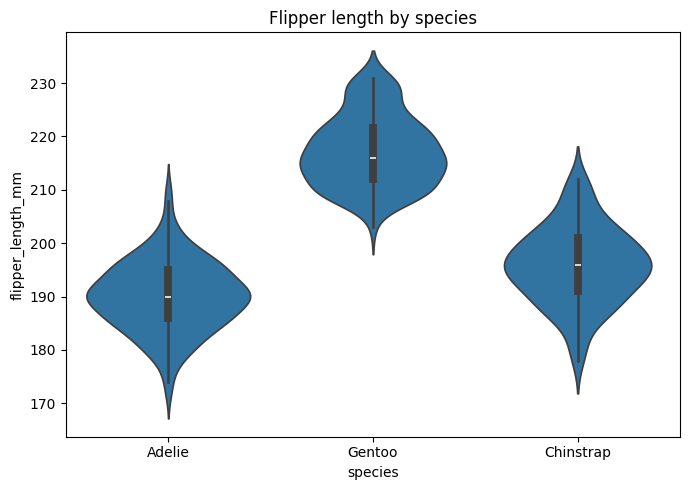

In [ ]:
# Step 1: broad scan (already done above with the pairplot)
# Step 2: pick a question -- does flipper length differ meaningfully by species?

# Step 3a: distribution check
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=penguins, x="species", y="flipper_length_mm", ax=ax)
ax.set_title("Flipper length by species")
plt.tight_layout()
plt.show()

In [ ]:
#Step 3b: shape check. Does the distribution look close to normal, or does it have a real skew worth noting?
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(penguins["flipper_length_mm"], dist="norm", plot=ax)
ax.set_title("Q-Q plot: flipper length, all species")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Step 4: outlier check, species by species
for species, group in penguins.groupby("species"):
    n_out = len(iqr_outliers(group["flipper_length_mm"]))
    print(f"{species}: {n_out} outlier(s) in flipper_length_mm")

Adelie: 2 outlier(s) in flipper_length_mm
Chinstrap: 0 outlier(s) in flipper_length_mm
Gentoo: 0 outlier(s) in flipper_length_mm


**Step 5, the written finding:** Gentoo penguins have noticeably longer flippers than Adelie or Chinstrap, with little overlap between Gentoo and the other two species. Adelie and Chinstrap overlap substantially with each other. No species shows a meaningful number of IQR outliers in flipper length, so this looks like a genuine, clean species difference rather than an artifact of a few unusual individuals.

That five-step shape, broad scan, pick a question, check distribution, check outliers, write a finding, is the pattern you'll repeat on your own data in the EDA project.

## On your own

Pick **one** relationship in `penguins` we have not already examined in this lab (a different pair of variables, or a different categorical split than species). Choose the plot type from this lab that best answers your question, build it, and in a markdown cell below, write 2-3 sentences on what you chose and why it was the right tool for the question, not just any tool that would show the data.

In [ ]:
# TODO: Your code here

*Your written answer here.*

## Submission

Export this notebook to HTML (`Jupyter: Export to HTML` from the Command Palette, or the "..." menu in the notebook toolbar) and submit the HTML file on Canvas.